# Homework 8: K-Means Clustering and Image Segmentaton
**Name:** Nicholas Starace  
**Student ID:** 4556822  
**D Value:** 22  

## Question 1: Conceptual Foundations

### Part A: Supervised vs. Unsupervised

**Written Response:**  
1. K-means is considered an unsupervised algorithm because it doesn't target an expected output in the training set but rather creates its own. In place of a target output, the user specifies a number of groups (classes) that the algorithm can use and places the data in class outputs on its own.  
2. The cost function minimized for linear regression finds a local minimum by performing gradient descent. Similarly, while K-means doesn't have an output and therefore can't calculate error, it still iterates to find a local minimum on the distance of points to the center of the cluster (SSD). The theta used in K-means can be thought of the distances between a point and the center of the group which is minimized. Predicting in K-means involves placing the point in a group where the sum of squared distances is smallest.  

### Part B: Convergence and Initialization

**Written Response:**  
1. SSD can never increase after updating points to clusters or updating cluster centers becuase the sum of squared distances will never increase. Updating centers brings them closer to all points. If SSD was to increase, this would mean that the cluster center is moving away from the optimal groupings. The steps converge to a local minimum and increasing SSD would go against the gradient.  
2. Just because SSD never increases doesn't guarantee that K-means always find the global optimal clustering. Similar to the optimzation problem addressed in HW6 neural networks, SSD iteration only guarantees a local minimum and will never go against the gradient. Therefore, even if K-means converges and settles on a specific cluster that is incorrect, the nature of weight initialization led the algorithm to a local minimum. Continung convergence for this weight initalization would require increasing SSD which we know is not possible. 

### Part C: Choosing K

**Written Response:** To choose the number of clusters (K), one can visualize the dataset before processing. This enables the user to have an intuitive understanding and ballpark of how many clusters should be used. If the data is higher dimension, the user can visualize two or three features at a time to find number of clusters. Other methods include training multiple models that iterate through K and evaluating testing performance or using silhouette coefficients. 

## Question 2: Implementing K-Means

### Part A: Single-Run K-Means

In [572]:
import os
import cv2
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
D = 22

In [573]:
# Implement K-Means
def kmeans_single(X, K, iters, random_seed):
    # Select K random samples of X
    np.random.seed(random_seed)
    randArr = np.random.permutation(X.shape[0])
    K_centers = X[randArr[0:K]]
    SSD = np.zeros(iters)

    for j in range(iters):

        # Calculate Euclidean Distance
        Dist = scipy.spatial.distance.cdist(X, K_centers, metric='euclidean')
    
        # Assign Samples to Cluster
        Cluster = np.argmin(Dist, axis=1)                            # Extract index of minimum distance -> belongs to cluster

        for i in range(K):

            # Find Cluster Center
            ClusterI = X[i == Cluster]                              # Extract Samples of ith cluster
            K_centers[i] = ClusterI.mean(axis=0)                    # Find Cluster Center

            # Find and Store SSD
            SSD[j] += np.sum((ClusterI - K_centers[i]) ** 2)         # Distance of sample to center squared vector

    ids = Cluster
    means = K_centers
    ssd_history = SSD
    return ids, means, ssd_history

### Part B: Verificaton on Toy Dataset

Hand Verification  
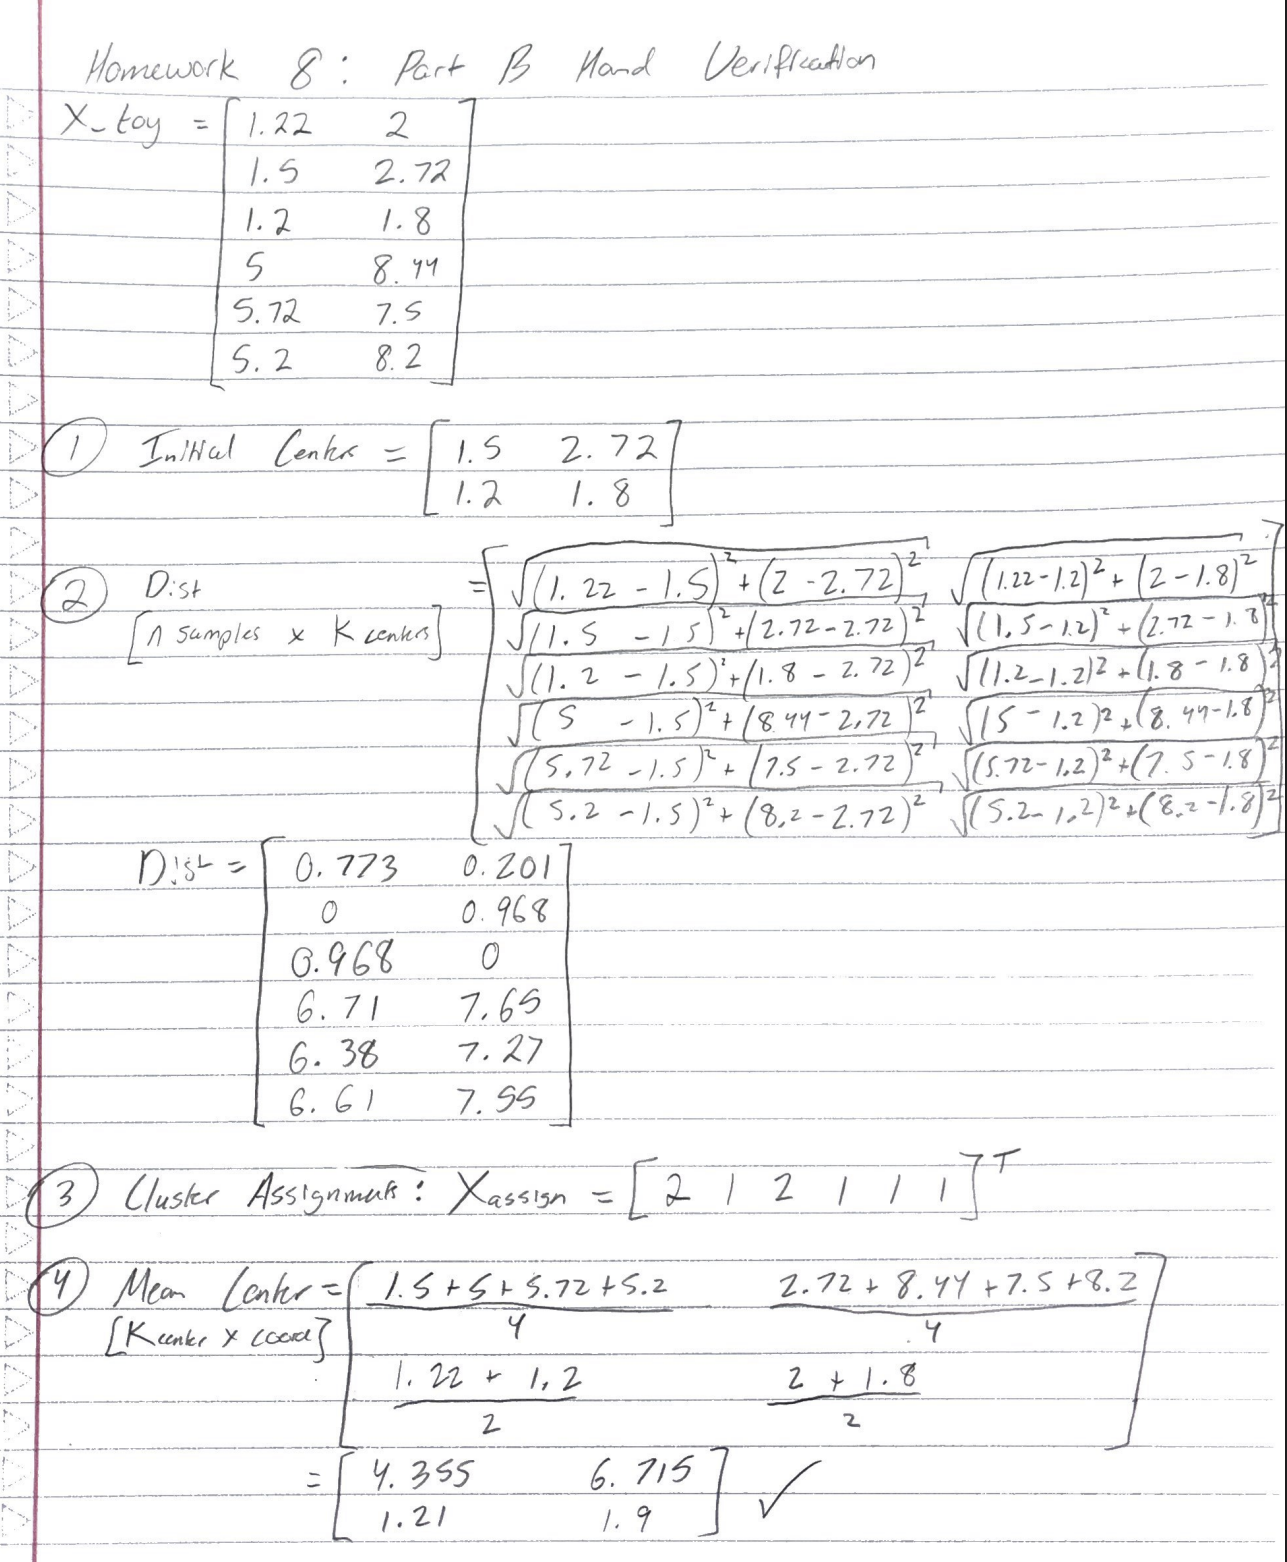

1.2778666666666658


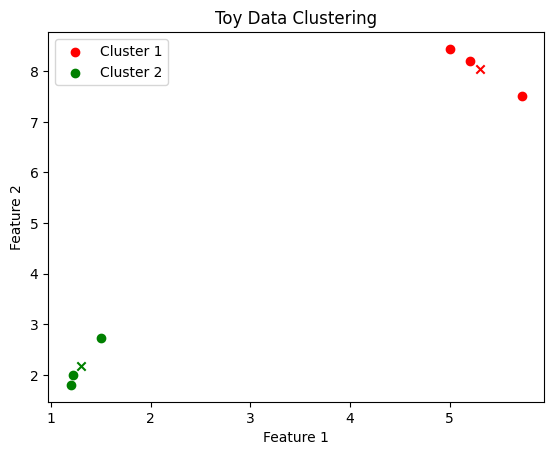

In [574]:
# Test K-Means on Toy Dataset
X_toy = np.array([[1.0 + D/100, 2.0], [1.5, 2.5 + D/100], [1.2, 1.8], [5.0, 8.0 + D/50], [5.5 + D/100, 7.5], [5.2, 8.2]])
K = 2
iters = 10
random_seed = D

# Run K-Means
ids, means, ssd_history = kmeans_single(X_toy, K, iters, random_seed)

# Visualize Results
X1 = X_toy[ids == 0]
X2 = X_toy[ids == 1]
plt.scatter(X1[:, 0], X1[:, 1], color="red", label="Cluster 1")
plt.scatter(X2[:, 0], X2[:, 1], color="green", label="Cluster 2")
plt.scatter(means[0, 0], means[0, 1], color="red", marker="x")
plt.scatter(means[1, 0], means[1, 1], color="green", marker="x")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Toy Data Clustering")
plt.legend(loc="upper left")

print(ssd_history[ssd_history.shape[0]-1])

**Written Response:** K-means correctly separates the groups of the toy data.  
Final SSD = 0.545  
This SSD matches the expected output since the center of the clusters don't lie directly on the points. 

### Part C: Multiple Restarts

In [575]:
# Wrapper Function
def kmeans_multiple(X, K, iters, R, base_seed):

    # Initialize Seed Counter and Returned Variables
    currentSeed = base_seed
    ids_best = np.zeros([X.shape[0], 1])
    means_best = np.zeros([K, X.shape[1]])
    ssd_best = np.zeros(iters)
    ssdBestLast = 1e9

    # Run K-means R Times
    for i in range(R):

        # Update Seed
        currentSeed = base_seed + i

        # Run K-means
        ids, means, ssd_history = kmeans_single(X, K, iters, currentSeed)

        # Compare if Lower SSD
        if ssd_history[iters-1] < ssdBestLast:
            ssdBestLast = ssd_history[iters-1]
            ids_best = ids
            means_best = means
            ssd_best = ssd_history

    return ids_best, means_best, ssdBestLast, ssd_best 

In [576]:
# Test K-Means Multiple on Toy Dataset
iters = 10
R = 5
base_seed = D

# Run K-Means Multiple
ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, base_seed)
print(best_ssd)

1.2778666666666658


**Written Response:** While running multiple K-means results in the same performance as the single K-means run, this result can be credited with the clearly defined clusters. In addition, by initializing the cluster centers at points in the dataset, the performance between single and multiple will be comprable.  
Lowest SSD = 1.278

### Part D: Convergence Analysis

Text(0.5, 1.0, 'SSD Convergence History')

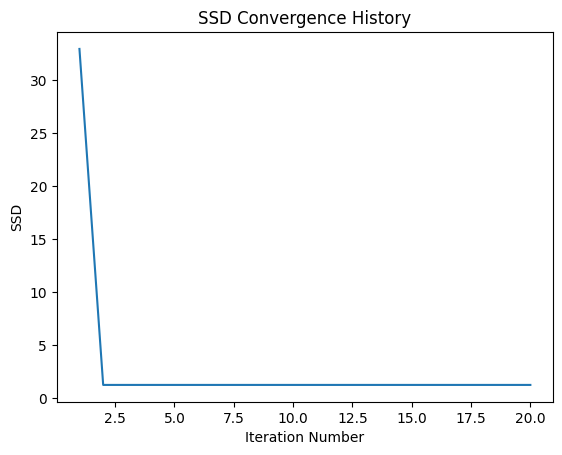

In [577]:
# Run K-means multiple with 20 iterations
X_toy = np.array([[1.0 + D/100, 2.0], [1.5, 2.5 + D/100], [1.2, 1.8], [5.0, 8.0 + D/50], [5.5 + D/100, 7.5], [5.2, 8.2]])
K = 2
base_seed = D
iters = 20
R = 5

ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, base_seed)

# Plot Convergence History
iterVec = np.arange(iters) + 1
plt.plot(iterVec, best_ssd_history)
plt.xlabel("Iteration Number")
plt.ylabel("SSD")
plt.title("SSD Convergence History")


**Written Response:** SSD stops changing around the second iteration. While this result is accurate and safe since the SSD converges rather than diverges, not all iterations are necessary. Comparing to gradent descent, this result would encourage a decrease in the step size due to quick convergence. 

## Question 3: Image Segmentation

### Part A: Data Preparation

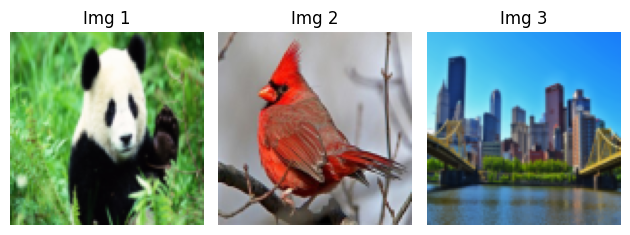

In [578]:
# Load Images
folder = './input/'
photos = sorted(os.listdir(folder))
imgs = []
labels = []

im1 = cv2.imread(os.path.join(folder, photos[0]))
im2 = cv2.imread(os.path.join(folder, photos[1]))
im3 = cv2.imread(os.path.join(folder, photos[2]))

# Convert to Float
im1 = im1 / 255.0
im2 = im2 / 255.0
im3 = im3 / 255.0

# Resize
im1 = resize(im1, (100, 100))
im2 = resize(im2, (100, 100))
im3 = resize(im3, (100, 100))
imAll = np.array([im1, im2, im3])

# Reshape for Storage
X1 = np.reshape(im1, (100*100, 3))
X2 = np.reshape(im2, (100*100, 3))
X3 = np.reshape(im3, (100*100, 3))
Xall = np.array([X1, X2, X3])

# Display Images
for i in range(3):
    imgshow = imAll[i][:, :, ::-1] # Flip BGR to RGB
    plt.subplot(1, 3, i + 1)
    plt.imshow(imgshow)
    plt.title(f"Img {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Part B: Segmentation - Single Run vs. Multiple Restarts

In [579]:
# Segment Helper Function
def segment_image(im, K, iters, R, base_seed):
    
    # Run K-means multiple
    ids, means, best_ssd, best_ssd_history = kmeans_multiple(im, K, iters, R, base_seed)

    # Recolor image
    Krecolor = im.copy()
    for i in range(K):
        Krecolor[ids == i] = means[i]

    return Krecolor, best_ssd


Personalized Parameter Calculations  
K = 3 + (22 % 4) --> 22/4 = 5R2 --> K = 3 + 2 = 5  
iters = 15 + (22 % 10) --> 22/10 = 2R2 --> iters = 15 + 2 = 17  
R = 5 + (22 % 5) --> 22/5 = 4R2 --> R = 5 + 2 = 7  
base_seed = 22   

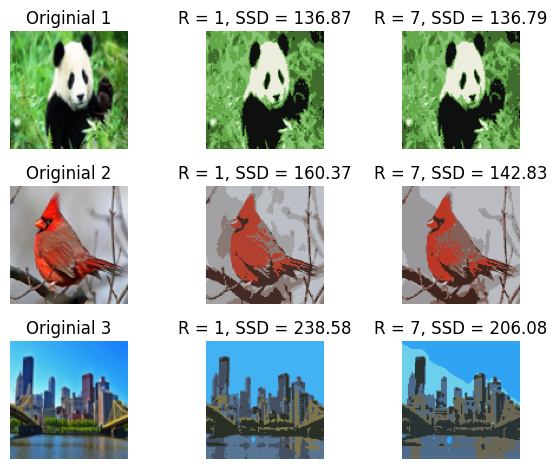

In [580]:
# Personalization Parameters
K = 3 + (D % 4)
iters = 15 + (D % 10)
R = 5 + (D % 5)
base_seed = D

SSDR = np.zeros((3, 2))

# Iterate Through Photos
k = -2
for i in range(3):
    k = k + 3

    # Select Photo of Interest
    X = Xall[i]

    # Run 1
    R = 1
    KrecolorSingle, best_ssd = segment_image(X, K, iters, R, base_seed)
    SSDR[i, 0] = best_ssd

    # Run 2
    R = 5 + (D % 5)
    KrecolorMultiple, best_ssd = segment_image(X, K, iters, R, base_seed)
    SSDR[i, 1] = best_ssd

    # Display Image Results
    plt.subplot(3, 3, k)
    plt.imshow(imAll[i][:, :, ::-1])
    plt.title(f"Originial {i+1}")
    plt.axis("off")

    plt.subplot(3, 3, k+1)
    plt.imshow(KrecolorSingle.reshape(100, 100, 3)[:, :, ::-1]) # Flip BGR to RGB
    plt.title(f"R = 1, SSD = {SSDR[i, 0]:.2f}")
    plt.axis("off")

    plt.subplot(3, 3, k+2)
    plt.imshow(KrecolorMultiple.reshape(100, 100, 3)[:, :, ::-1]) # Flip BGR to RGB
    plt.title(f"R = {R}, SSD = {SSDR[i, 1]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Written Response:** The clusters correspond to clear elements of the photo. For example, clusters in image clearly represent the bird, branches, and background. The clusters are visually meaningful since they correspond to the background, foreground, or subject of the photo.  
  
While the multi restart always results in a lower SSD and therefore better performance, the difference is not always visually noticable. For example, in image 1, the difference between R = 1 and 7 is not noticible but is in image 2. 

### Part C: Effect of K Segmentation

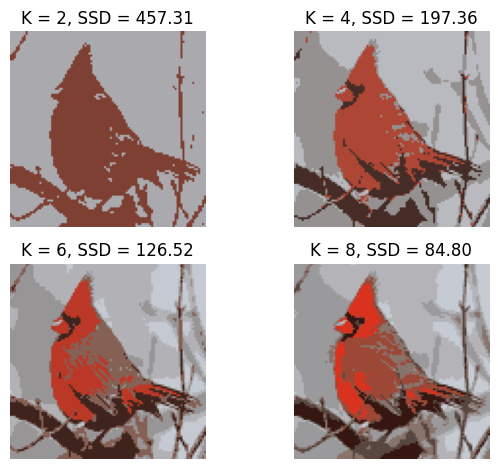

In [581]:
R = 5 + (D % 5)
Kfull = np.array([2, 4, 6, 8])

# Select Image 2: Cardinal
X = Xall[1]

SSD = np.zeros(4)
for i in range(4):

    K = Kfull[i]
    
    # Run Kmeans
    Krecolor, best_ssd = segment_image(X, K, iters, R, base_seed)
    SSD[i] = best_ssd

    # Display Image Results
    plt.subplot(2, 2, i+1)
    plt.imshow(Krecolor.reshape(100, 100, 3)[:, :, ::-1])
    plt.title(f"K = {Kfull[i]}, SSD = {SSD[i]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()



**Written Response:** The visual quality of the cardinal increases as K increases. With additional clusters, pixel values are closer to their respective mean value. For example, if K = 255, then the mean image would be identical to the original. Visual improvement begins to level off around K > 8. Clear resolution is lost and the image becomes pixelated when K s too low.  
  
For the best balance of simplicity and segmentation quality, I would visually select K = 3. The image clearly consists of a background, branches, and bird. At K = 2, the branches and bird are separated from the background. At K = 4, the bird begins to become segmented from itself. Therefore, for the simplest segmentation, 3 is optimal. 

### Part D: The Elbow Method

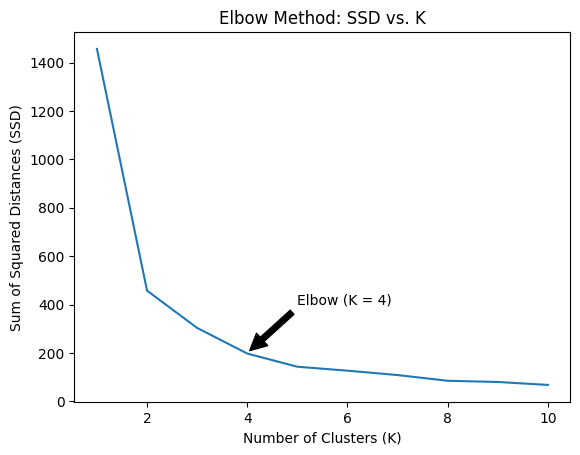

In [582]:
R = 5 + (D % 5)
Kfull = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Select Image 2: Cardinal
X = Xall[1]

SSD = np.zeros(10)
for i in range(10):

    K = Kfull[i]
    
    # Run Kmeans
    Krecolor, best_ssd = segment_image(X, K, iters, R, base_seed)
    SSD[i] = best_ssd

SSDElbow = SSD[3]

# Display Elbow Results
plt.plot(Kfull, SSD)
plt.title("Elbow Method: SSD vs. K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.annotate("Elbow (K = 4)", (4, 200), xytext=(5, 400), arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

**Written Response:**  
1. The elbow occurs around K = 4. SSD = 197.4  
2. The elbow differs by visual assessment by 1. It is more approprate to select visually K = 3 since the human understands that there are three objects present in the image (branches, bird, background).  
3. We do not pick the largest possible K because there would effectively be no grouping and the means image would look identical to the original. Selecting this large K is a form of overfitting for K-means. While it captures large variance, the model is biased towards the training data. Selecting too small of a K would lead to underfitting and large SSD. The model has no bias towards features of the data but captures small variance. 

## Question 4: Reflection and Synthesis

### Part A: Results Summary

In [583]:
print(SSDR)
print(SSDElbow)

[[136.86524949 136.79284536]
 [160.36890288 142.82925502]
 [238.58105045 206.07823499]]
197.35587723228474


| Image | K | R = 1 SSD | R = 7 SSD | Elbow K | SSD at Elbow |
|-------|---|-----------|-----------|---------| ------------ |
| 1     | 5 |   136.9   |   136.8   |         |              |
| 2     | 5 |   160.4   |   142.8   |    4    |    197.4     |
| 3     | 5 |   238.6   |   206.1   |         |              |

### Part B: Effect of Restarts

**Written Response:** The multi restart always found a lower SSD in question 3B. The improvements from R = 1 to R = 7 was deltaSSD = 0.1, 18, 30 for images 1, 2 and 3, respectively. The differences were more noticible in images with a larger gap in SSD. In image 1 with the panda, the difference of 0.1 SSD was not noticible at all. However, the difference of 30 SSD in image 3 was visually significant. Therefore, random initialization and therefore multiple K-means iterations plays a significant role in finding the lowest SSD. 

### Part C: Limitations of K-Means

**Written Response:** Because K-means relies on Euclidean distance in the color domain, it is blind to capturing features such as edges or patterns that other algorithms like CNNs might find. For example, K-means would perform poorly attempting to separate a an image of a lake on a clear day. While a viewer can clearly separate a lake from the sky, the K-means algorthm may fail to separate the two. Specifically, a blue lake will have nearly the same color as a clear blue sky, making the two objects blind to K-means.  

I expect that K-means would perform poorly on the Vehicles dataset due to the poor resolution grayscale images. The 1024 resolution images are small enough that a white airplane in the blue sky casted to grayscale will exhibit very similar pixel values (>125). If you can visually separate a plane from the background (K = 2), K-means will see the similar pixel values as the same class and perform poorly. Even worse would be attempting to determine cars from planes from trucks which will have similar if not identical colors.   

### Part D: K-Means as a Preprocessing Step

**Written Response:** K-means is useful for preprocessing because it can be considered a form of normalization. For example, trying to classfy images of fruits would be made simpler by only looking at the fruit color and ignoring the background. Running K-means on this data with K = 2 will do a good job of separating a homogeneous fruits from the background. From there, the initial picture wth a pixel range of 0-255 has been simplified to only two values. This eliminates noise in the photo and effectively regularizes the data for a supervised classification. To actually classify a fruit as a bananna, apple, etc. K-means is incapable of assigning labels. While it can create groups, a supervised approach with training data surpasses K-means.  

### Part E: Course Arc

**Written Response:** To ensure that K-means was functioning correctly, it vital that SSD decreased as K increased. In earlier assignments, it was understood that minimizing cost across iterations was the driving factor for algorithm accuracy. The optimization problem of converging on a local minimum was understood by graphing the cost function and finding a diminishing improvement. Similar to the cost minimization performed in previous assignments, the optimization problem presented here of minimizing SSD enabled understanding the elbow method for an optimal K. By finding convergence of SSD, the optimal K could be found. Additionally, understanding dimensionality reduction through PCA enabled understanding the significance of using K-means as a preprocessing step for supervised learning.  